# Our classifier study

## Importations

In [113]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.effects

# ML imports
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_fscore_support)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

# Custom utilities (from your provided code)
from classification.datasets import Dataset
from classification.utils.audio_student import AudioUtil, Feature_vector_DS
from classification.utils.utils import accuracy
from classification.utils.plots import (
    plot_decision_boundaries,
    plot_specgram,
    show_confusion_matrix,
)

import pickle

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# Set reproducibility
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
GPU Available: []


## Config

In [114]:
class Config:
    """Centralized configuration"""
    
    # Audio parameters
    SAMPLE_RATE = 11025
    DURATION_MS = 950
    N_FFT = 512
    N_MEL = 20
    STEP_SIZE = 51
    
    # Data augmentation flags
    AUG_TIME_SHIFT = True
    AUG_PITCH_SHIFT = True
    AUG_TIME_STRETCH = True
    AUG_NOISE = True
    AUG_SPEC_MASKING = True
    
    # Augmentation parameters
    PITCH_SHIFT_RANGE = (-2, 2)  # semitones
    TIME_STRETCH_RANGE = (0.9, 1.1)
    NOISE_SIGMA = 0.05
    
    # Model architecture
    DENSE_UNITS = [256, 128, 64]
    DROPOUT_RATE = 0.3
    ACTIVATION = 'relu'
    
    # Training
    BATCH_SIZE = 32
    EPOCHS = 10000
    LEARNING_RATE = 0.0001
    VALIDATION_SPLIT = 0.2
    TEST_SPLIT = 0.2
    
    # Callbacks
    EARLY_STOPPING_PATIENCE = 300
    REDUCE_LR_PATIENCE = 50
    REDUCE_LR_FACTOR = 0.5
    
    # Paths
    MODEL_DIR = "./data/models/models_cnn/"
    
    # Decision strategy
    DECISION_STRATEGY = 'max_probability'
    CONFIDENCE_THRESHOLD = 0.6
    TEMPERATURE = 1.0

config = Config()

## Data augmentation

In [115]:
class AdvancedAudioAugmentation:
    """Advanced augmentation: time-shift, pitch-shift, time-stretch"""
    
    @staticmethod
    def time_shift(audio, shift_max=0.2):
        sig, sr = audio
        shift_amount = int(np.random.uniform(-shift_max, shift_max) * len(sig))
        sig_shifted = np.roll(sig, shift_amount)
        return (sig_shifted, sr)
    
    @staticmethod
    def pitch_shift(audio, n_steps_range=(-2, 2)):
        sig, sr = audio
        n_steps = np.random.uniform(n_steps_range[0], n_steps_range[1])
        sig_shifted = librosa.effects.pitch_shift(sig, sr=sr, n_steps=n_steps)
        return (sig_shifted, sr)
    
    @staticmethod
    def time_stretch(audio, rate_range=(0.9, 1.1)):
        sig, sr = audio
        rate = np.random.uniform(rate_range[0], rate_range[1])
        sig_stretched = librosa.effects.time_stretch(sig, rate=rate)
        
        if len(sig_stretched) > len(sig):
            sig_stretched = sig_stretched[:len(sig)]
        elif len(sig_stretched) < len(sig):
            sig_stretched = np.pad(sig_stretched, (0, len(sig) - len(sig_stretched)))
        return (sig_stretched, sr)
    
    @staticmethod
    def apply_augmentation_pipeline(audio, config):
        """Apply full augmentation pipeline"""
        if config.AUG_TIME_SHIFT and np.random.random() > 0.5:
            audio = AdvancedAudioAugmentation.time_shift(audio)
        
        if config.AUG_PITCH_SHIFT and np.random.random() > 0.5:
            audio = AdvancedAudioAugmentation.pitch_shift(
                audio, n_steps_range=config.PITCH_SHIFT_RANGE)
        
        if config.AUG_TIME_STRETCH and np.random.random() > 0.5:
            audio = AdvancedAudioAugmentation.time_stretch(
                audio, rate_range=config.TIME_STRETCH_RANGE)
        
        if config.AUG_NOISE and np.random.random() > 0.5:
            audio = AudioUtil.add_noise(audio, sigma=config.NOISE_SIGMA)
        
        return audio


class AugmentedFeatureVectorDS(Feature_vector_DS):
    """Extended Dataset with advanced augmentation + FIXES"""
    
    def __init__(self, *args, use_advanced_aug=False, config=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.use_advanced_aug = use_advanced_aug
        self.config = config or Config()
    
    def get_audiosignal(self, cls_index):
        audio_file = self.dataset[cls_index]
        aud = AudioUtil.open(audio_file)
        aud = AudioUtil.resample(aud, self.sr)
        
        if self.use_advanced_aug:
            aud = AdvancedAudioAugmentation.apply_augmentation_pipeline(
                aud, self.config)
        
        if self.data_aug is not None:
            if "add_bg" in self.data_aug:
                aud = AudioUtil.add_bg(aud, self.dataset, num_sources=1,
                                      max_ms=self.duration, amplitude_limit=0.1)
            if "echo" in self.data_aug:
                aud = AudioUtil.echo(aud)
            if "noise" in self.data_aug:
                aud = AudioUtil.add_noise(aud, sigma=0.05)
            if "scaling" in self.data_aug:
                aud = AudioUtil.scaling(aud, scaling_limit=5)
        
        aud = (aud[0] / (np.max(np.abs(aud[0])) + 1e-8), aud[1])
        return aud
    
    def __getitem__(self, cls_index):
        aud = self.get_audiosignal(cls_index)
        sgram = AudioUtil.melspectrogram(aud, Nmel=self.nmel, Nft=self.Nft)
        
        if self.use_advanced_aug and self.config.AUG_SPEC_MASKING:
            if np.random.random() > 0.5:
                sgram = AudioUtil.spectro_aug_timefreq_masking(
                    sgram, max_mask_pct=0.1, n_freq_masks=2, n_time_masks=2)
        
        return sgram
    
    def treat_spec(self, sgram):
        """
        FIX: Gère les spectrogrammes de tailles variables 
        en garantissant des feature vectors de taille fixe
        """
        # Calculer le nombre de colonnes dans le spectrogram
        n_cols = sgram.shape[1]
        
        # S'assurer que le spectrogram est assez grand
        if n_cols < self.ncol:
            # Pad le spectrogram s'il est trop petit
            pad_width = self.ncol - n_cols
            sgram = np.pad(sgram, ((0, 0), (0, pad_width)), mode='constant', constant_values=0)
            n_cols = sgram.shape[1]
        
        # Calculer les indices pour le sliding window
        indexes = np.arange(0, n_cols - self.ncol + 1, self.step, dtype=int)
        
        # S'assurer qu'il y a au moins un index
        if len(indexes) == 0:
            indexes = np.array([0])
        
        # Extraire les fenêtres
        sgrams = []
        for i in indexes:
            window = sgram[:, i : i + self.ncol]
            # Double check: s'assurer que la fenêtre a la bonne taille
            if window.shape[1] < self.ncol:
                # Pad si nécessaire
                pad_width = self.ncol - window.shape[1]
                window = np.pad(window, ((0, 0), (0, pad_width)), mode='constant', constant_values=0)
            sgrams.append(window)
        
        sgrams = np.array(sgrams)
        
        # Flatten en feature vectors
        fv = sgrams.reshape(sgrams.shape[0], -1)
        
        if self.normalize:
            # Éviter division par zéro
            norms = np.linalg.norm(fv, axis=1, keepdims=True)
            norms[norms == 0] = 1.0
            fv = fv / norms
        
        if self.pca is not None:
            fv = np.array([self.pca.transform([i])[0] for i in fv])
        
        return fv

## Data preparation

In [116]:
def prepare_dataset(dataset, config, use_augmentation=True):
    """Prepare datasets with augmentation"""
    print("="*80)
    print("DATA PREPARATION")
    print("="*80)
    
    classnames = dataset.list_classes()
    print(f"Classes: {classnames}")
    print(f"Number of classes: {len(classnames)}")
    
    # Create dataset
    print("\nCreating feature vectors with augmentation...")
    myds = AugmentedFeatureVectorDS(
        dataset, Nft=config.N_FFT, nmel=config.N_MEL, 
        duration=config.DURATION_MS, step=config.STEP_SIZE,
        use_advanced_aug=use_augmentation, config=config
    )
    
    X, y = myds.get_feature_vectors()
    print(f"Dataset shape: {X.shape}")
    print(f"Samples per class: {X.shape[0] // len(classnames)}")
    
    # Convert labels to numerical
    label_to_idx = {label: idx for idx, label in enumerate(classnames)}
    y_numeric = np.array([label_to_idx[label] for label in y])
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_numeric, test_size=config.TEST_SPLIT, 
        stratify=y_numeric, random_state=42
    )
    
    print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
    
    # L2 normalization
    print("\nApplying L2 normalization...")
    X_train_norm = X_train / (np.linalg.norm(X_train, axis=1, keepdims=True) + 1e-8)
    X_test_norm = X_test / (np.linalg.norm(X_test, axis=1, keepdims=True) + 1e-8)
    
    # One-hot encoding
    y_train_cat = to_categorical(y_train, num_classes=len(classnames))
    y_test_cat = to_categorical(y_test, num_classes=len(classnames))
    
    return X_train_norm, X_test_norm, y_train_cat, y_test_cat, y_train, y_test, classnames


## Linear CNN Model

In [117]:
def build_linear_cnn_model(input_shape, num_classes, config):
    """
    CNN with Dense/Linear layers instead of convolutions.
    Dense layers perform linear combinations of features.
    """
    print("\n" + "="*80)
    print("MODEL ARCHITECTURE: LINEAR CNN")
    print("="*80)
    
    model = models.Sequential(name="LinearCNN")
    
    # Input
    model.add(layers.Input(shape=input_shape, name="input"))
    
    # Dense block 1
    model.add(layers.Dense(config.DENSE_UNITS[0], activation=config.ACTIVATION,
                          name="linear_block_1"))
    model.add(layers.BatchNormalization(name="bn_1"))
    model.add(layers.Dropout(config.DROPOUT_RATE, name="dropout_1"))
    
    # Dense block 2
    model.add(layers.Dense(config.DENSE_UNITS[1], activation=config.ACTIVATION,
                          name="linear_block_2"))
    model.add(layers.BatchNormalization(name="bn_2"))
    model.add(layers.Dropout(config.DROPOUT_RATE, name="dropout_2"))
    
    # Dense block 3
    model.add(layers.Dense(config.DENSE_UNITS[2], activation=config.ACTIVATION,
                          name="linear_block_3"))
    model.add(layers.BatchNormalization(name="bn_3"))
    model.add(layers.Dropout(config.DROPOUT_RATE, name="dropout_3"))
    
    # Output with softmax
    model.add(layers.Dense(num_classes, activation='softmax', name="output"))
    
    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config.LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=2)]
    )
    
    model.summary()
    print(f"\nTotal parameters: {model.count_params():,}")
    print(f"Model size: ~{model.count_params() * 4 / 1024:.2f} KB (FP32)")
    
    return model

## Training

In [118]:
def train_model(model, X_train, y_train, X_val, y_val, config):
    """Train with callbacks"""
    print("\n" + "="*80)
    print("TRAINING")
    print("="*80)
    
    os.makedirs(config.MODEL_DIR, exist_ok=True)
    
    callback_list = [
        callbacks.EarlyStopping(monitor='val_loss', patience=config.EARLY_STOPPING_PATIENCE,
                               restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=config.REDUCE_LR_FACTOR,
                                   patience=config.REDUCE_LR_PATIENCE, min_lr=1e-7, verbose=1),
        callbacks.ModelCheckpoint(config.MODEL_DIR + 'best_model.h5',
                                 monitor='val_accuracy', save_best_only=True, verbose=1)
    ]
    
    print(f"Epochs: {config.EPOCHS}, Batch: {config.BATCH_SIZE}")
    print(f"Train: {len(X_train)}, Val: {len(X_val)}")
    
    history = model.fit(
        X_train, y_train, batch_size=config.BATCH_SIZE, epochs=config.EPOCHS,
        validation_data=(X_val, y_val), callbacks=callback_list, verbose=1
    )
    
    with open(config.MODEL_DIR + 'history.pkl', 'wb') as f:
        pickle.dump(history.history, f)
    
    return history

## Decision strategies

In [119]:
class DecisionStrategy:
    """Advanced decision strategies for classification"""
    
    @staticmethod
    def max_probability(probs, threshold=None):
        """Select class with max probability"""
        pred_class = np.argmax(probs)
        if threshold and probs[pred_class] < threshold:
            return -1  # Uncertain
        return pred_class
    
    @staticmethod
    def temperature_scaling(probs, temperature=1.0):
        """Apply temperature scaling for calibration"""
        logits = np.log(probs + 1e-10)
        scaled_logits = logits / temperature
        return np.exp(scaled_logits) / np.sum(np.exp(scaled_logits))
    
    @staticmethod
    def top_k_voting(probs, k=2):
        """Top-k predictions with gap analysis"""
        top_k_idx = np.argsort(probs)[-k:][::-1]
        top_k_probs = probs[top_k_idx]
        return {
            'classes': top_k_idx,
            'probabilities': top_k_probs,
            'gap': top_k_probs[0] - top_k_probs[1] if k > 1 else 1.0
        }

## Evaluation

In [120]:
def evaluate_model(model, X_test, y_test, classnames, config):
    """Comprehensive evaluation"""
    print("\n" + "="*80)
    print("EVALUATION")
    print("="*80)
    
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    test_acc = np.mean(y_pred == y_true)
    print(f"\nTest Accuracy: {100 * test_acc:.2f}%")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.colorbar()
    tick_marks = np.arange(len(classnames))
    plt.xticks(tick_marks, classnames, rotation=45, ha='right')
    plt.yticks(tick_marks, classnames)
    
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')
    plt.tight_layout()
    plt.savefig(config.MODEL_DIR + 'confusion_matrix.png', dpi=300)
    plt.show()
    
    # Per-class metrics
    print("\nPer-Class Metrics:")
    print(f"{'Class':<15} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print("-" * 65)
    
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(classnames)), average=None
    )
    
    for i, cls in enumerate(classnames):
        print(f"{cls:<15} {precision[i]:>10.3f} {recall[i]:>10.3f} "
              f"{f1[i]:>10.3f} {int(support[i]):>10}")
    
    # Confidence analysis
    print("\nConfidence Analysis:")
    max_probs = np.max(y_pred_probs, axis=1)
    print(f"  Mean confidence: {np.mean(max_probs):.3f}")
    print(f"  Median confidence: {np.median(max_probs):.3f}")
    
    return {'accuracy': test_acc, 'confusion_matrix': cm, 
            'predictions': y_pred, 'probabilities': y_pred_probs}

## Visualisation

In [121]:
def plot_training_history(history, config):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss
    axes[1].plot(history.history['loss'], label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(config.MODEL_DIR + 'training_history.png', dpi=300)
    plt.show()
    
    best_epoch = np.argmax(history.history['val_accuracy'])
    print(f"\nBest val accuracy: {100*history.history['val_accuracy'][best_epoch]:.2f}% "
          f"at epoch {best_epoch + 1}")

## Main pipeline

In [122]:
def main_pipeline(dataset, config):
    """Complete training pipeline"""
    print("\n" + "="*80)
    print("LINEAR CNN AUDIO CLASSIFIER - PIPELINE")
    print("="*80)
    
    # Prepare data
    X_train, X_test, y_train_cat, y_test_cat, y_train, y_test, classnames = \
        prepare_dataset(dataset, config, use_augmentation=True)
    
    # Validation split
    X_train_final, X_val, y_train_final, y_val = train_test_split(
        X_train, y_train_cat, test_size=config.VALIDATION_SPLIT,
        stratify=y_train, random_state=42
    )
    
    print(f"\nSplits: Train={X_train_final.shape[0]}, "
          f"Val={X_val.shape[0]}, Test={X_test.shape[0]}")
    
    # Build model
    model = build_linear_cnn_model(
        input_shape=(X_train.shape[1],),
        num_classes=len(classnames),
        config=config
    )
    
    # Train
    history = train_model(model, X_train_final, y_train_final, X_val, y_val, config)
    
    # Plot history
    plot_training_history(history, config)
    
    # Load best model and evaluate
    best_model = keras.models.load_model(config.MODEL_DIR + 'best_model.h5')
    metrics = evaluate_model(best_model, X_test, y_test_cat, classnames, config)
    
    # Save model
    print("\n" + "="*80)
    print("SAVING MODEL")
    print("="*80)
    
    best_model.save(config.MODEL_DIR + 'final_model.h5')
    print(f"Keras model saved: {config.MODEL_DIR}final_model.h5")
    
    # Save config
    model_config = {
        'classnames': classnames,
        'input_shape': (X_train.shape[1],),
        'n_mel': config.N_MEL,
        'n_fft': config.N_FFT,
        'sample_rate': config.SAMPLE_RATE,
        'test_accuracy': metrics['accuracy']
    }
    with open(config.MODEL_DIR + 'model_config.pkl', 'wb') as f:
        pickle.dump(model_config, f)
    
    # Export to TensorFlow Lite (for embedded)
    try:
        converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        tflite_model = converter.convert()
        
        with open(config.MODEL_DIR + 'model.tflite', 'wb') as f:
            f.write(tflite_model)
        print(f"TFLite model: {config.MODEL_DIR}model.tflite ({len(tflite_model)/1024:.2f} KB)")
    except Exception as e:
        print(f"TFLite conversion error: {e}")
    
    print("\n" + "="*80)
    print("COMPLETE - Ready for MCU+FPGA deployment!")
    print(f"Test Accuracy: {100 * metrics['accuracy']:.2f}%")
    print("="*80)
    
    return best_model, metrics, classnames

##  INFERENCE FOR EMBEDDED DEPLOYMENT

In [123]:
def inference_for_embedded(model, feature_vector, classnames, config):
    """
    Optimized inference for embedded deployment.
    Receives feature vectors from LimeSDR wireless link.
    """
    if len(feature_vector.shape) == 1:
        feature_vector = feature_vector.reshape(1, -1)
    
    # L2 normalization
    feature_vector_norm = feature_vector / \
        (np.linalg.norm(feature_vector, axis=1, keepdims=True) + 1e-8)
    
    # Predict
    prob_vector = model.predict(feature_vector_norm, verbose=0)[0]
    
    # Decision strategy
    predicted_idx = DecisionStrategy.max_probability(
        prob_vector, threshold=config.CONFIDENCE_THRESHOLD
    )
    
    # Top-k
    top_k = DecisionStrategy.top_k_voting(prob_vector, k=3)
    
    return {
        'predicted_class': classnames[predicted_idx] if predicted_idx >= 0 else 'UNCERTAIN',
        'confidence': prob_vector[predicted_idx] if predicted_idx >= 0 else 0.0,
        'probability_vector': prob_vector,
        'top_3': [(classnames[i], prob_vector[i]) for i in top_k['classes']],
        'decision_gap': top_k['gap']
    }


LINEAR CNN AUDIO CLASSIFIER - PIPELINE
DATA PREPARATION
Classes: ['chainsaw', 'fire', 'fireworks', 'gunshot']
Number of classes: 4

Creating feature vectors with augmentation...
Dataset shape: (527, 400)
Samples per class: 131

Train: (421, 400), Test: (106, 400)

Applying L2 normalization...

Splits: Train=336, Val=85, Test=106

MODEL ARCHITECTURE: LINEAR CNN


Model: "LinearCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ linear_block_1 (Dense)          │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ linear_block_2 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ linear_block_3 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,860 (569.77 KB)

 Trainable params: 144,964 (566.27 KB)

...

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6310 - loss: 0.8629 - top_k_categorical_accuracy: 0.9077 - val_accuracy: 0.6235 - val_loss: 1.0635 - val_top_k_categorical_accuracy: 0.8588 - learning_rate: 1.0000e-04
Epoch 72/10000
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5938 - loss: 0.9079 - top_k_categorical_accuracy: 0.9375
Epoch 72: val_accuracy did not improve from 0.62353
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6548 - loss: 0.8036 - top_k_categorical_accuracy: 0.9286 - val_accuracy: 0.6118 - val_loss: 1.0655 - val_top_k_categorical_accuracy: 0.8706 - learning_rate: 1.0000e-04
Epoch 73/10000
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7812 - loss: 0.7099 - top_k_categorical_accuracy: 0.8750
Epoch 73: val_accuracy did not improve from 0.62353
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6607 - loss: 0.8411 - top_k_categorical_accuracy: 0.8839 - val_accuracy: 0.6118 - val_loss: 1.0886 - val_top_k_categorical_accuracy: 0.8588 - learnin

[18:18:00] WARNING  You are saving your model as an HDF5 file via `model.save()` or                ]8;id=726114;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/saving/saving_api.py\saving_api.py]8;;\:]8;id=673855;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/saving/saving_api.py#83\83]8;;\
                    `keras.saving.save_model(model)`. This file format is considered legacy. We                    
                    recommend using instead the native Keras format, e.g.                                          
                    `model.save('my_model.keras')` or `keras.saving.save_model(model,                              
                    'my_model.keras')`.                                                                            

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7351 - loss: 0.7360 - top_k_categorical_accuracy: 0.9286 - val_accuracy: 0.6353 - val_loss: 1.0681 - val_top_k_categorical_accuracy: 0.8588 - learning_rate: 1.0000e-04
Epoch 90/10000
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6562 - loss: 0.9752 - top_k_categorical_accuracy: 0.8750
Epoch 90: val_accuracy did not improve from 0.63529
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6964 - loss: 0.7466 - top_k_categorical_accuracy: 0.9226 - val_accuracy: 0.6000 - val_loss: 1.0737 - val_top_k_categorical_accuracy: 0.8353 - learning_rate: 1.0000e-04
Epoch 91/10000
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5625 - loss: 1.1469 - top_k_categorical_accuracy: 0.8438
Epoch 91: val_accuracy did not improve from 0.63529
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6726 - loss: 0.7729 - top_k_categorical_accuracy: 0.9048 - val_accuracy: 0.5765 - val_loss: 1.0986 - val_top_k_categorical_accuracy: 0.8353 - learni

[18:18:02] WARNING  You are saving your model as an HDF5 file via `model.save()` or                ]8;id=678935;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/saving/saving_api.py\saving_api.py]8;;\:]8;id=179170;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/saving/saving_api.py#83\83]8;;\
                    `keras.saving.save_model(model)`. This file format is considered legacy. We                    
                    recommend using instead the native Keras format, e.g.                                          
                    `model.save('my_model.keras')` or `keras.saving.save_model(model,                              
                    'my_model.keras')`.                                                                            

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7619 - loss: 0.6424 - top_k_categorical_accuracy: 0.9345 - val_accuracy: 0.6706 - val_loss: 1.0982 - val_top_k_categorical_accuracy: 0.8824 - learning_rate: 1.0000e-04
Epoch 103/10000
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7812 - loss: 0.5629 - top_k_categorical_accuracy: 1.0000
Epoch 103: val_accuracy did not improve from 0.67059
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7292 - loss: 0.6927 - top_k_categorical_accuracy: 0.9345 - val_accuracy: 0.6353 - val_loss: 1.1064 - val_top_k_categorical_accuracy: 0.8824 - learning_rate: 1.0000e-04
Epoch 104/10000
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7188 - loss: 0.8126 - top_k_categorical_accuracy: 0.9688
Epoch 104: val_accuracy did not improve from 0.67059
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7083 - loss: 0.7164 - top_k_categorical_accuracy: 0.9464 - val_accuracy: 0.6471 - val_loss: 1.0885 - val_top_k_categorical_accuracy: 0.8706 - l

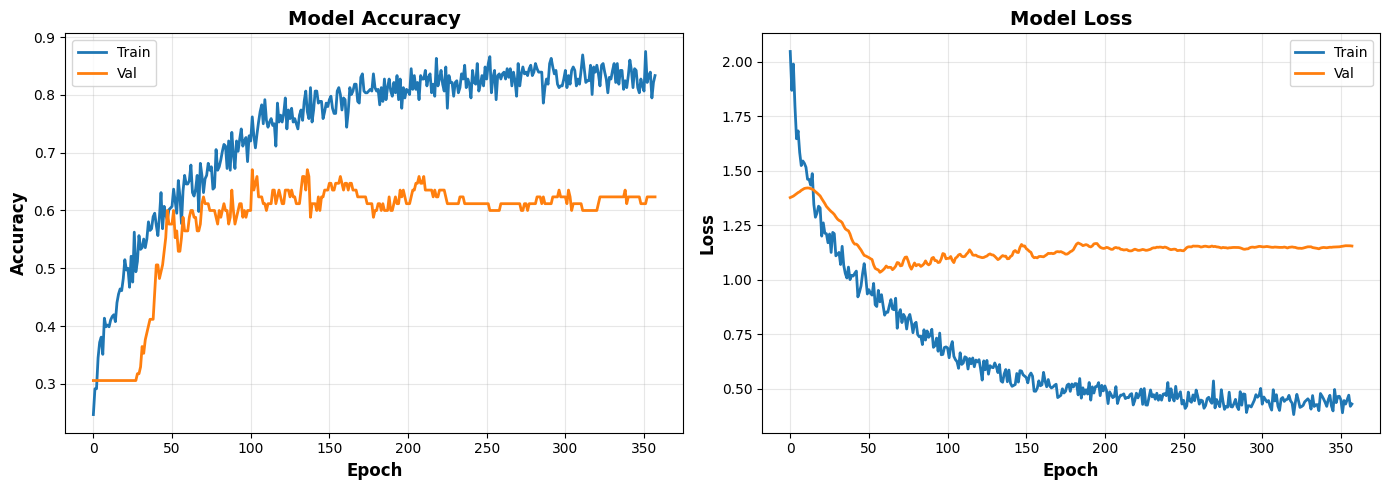


Best val accuracy: 67.06% at epoch 102


[18:18:30] WARNING  Compiled the loaded model, but the compiled metrics have yet to be built.   ]8;id=756483;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/legacy/saving/saving_utils.py\saving_utils.py]8;;\:]8;id=827623;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/legacy/saving/saving_utils.py#249\249]8;;\
                    `model.compile_metrics` will be empty until you train or evaluate the                          
                    model.                                                                                         


EVALUATION

Test Accuracy: 65.09%


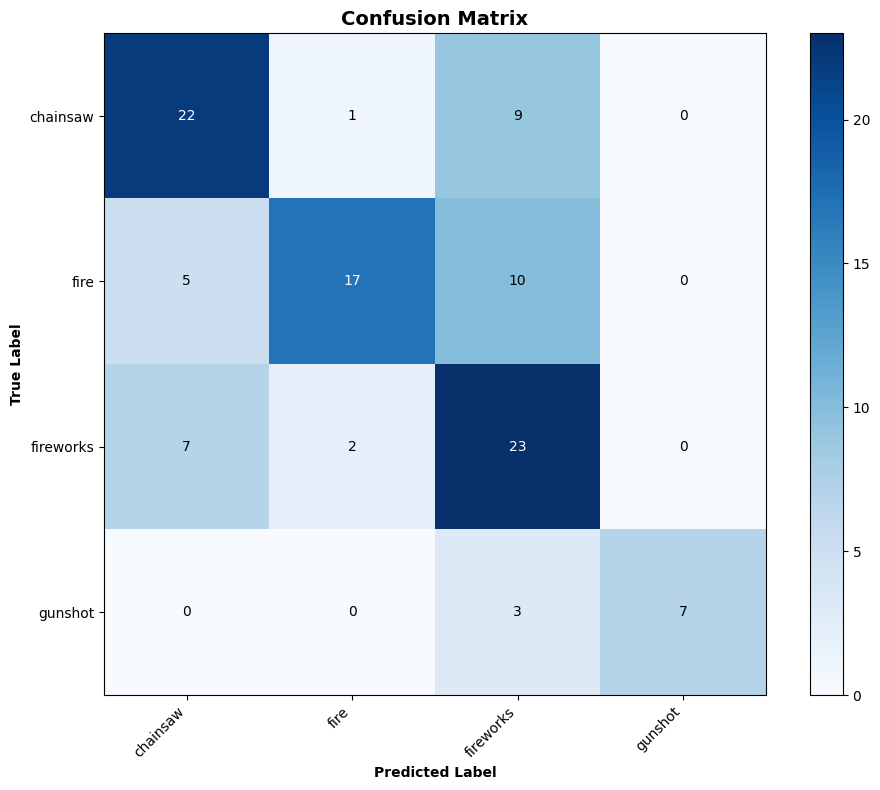


Per-Class Metrics:
Class            Precision     Recall         F1    Support
-----------------------------------------------------------------
chainsaw             0.647      0.688      0.667         32
fire                 0.850      0.531      0.654         32
fireworks            0.511      0.719      0.597         32
gunshot              1.000      0.700      0.824         10

Confidence Analysis:
  Mean confidence: 0.692
  Median confidence: 0.682

SAVING MODEL


           WARNING  You are saving your model as an HDF5 file via `model.save()` or                ]8;id=989421;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/saving/saving_api.py\saving_api.py]8;;\:]8;id=581852;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/saving/saving_api.py#83\83]8;;\
                    `keras.saving.save_model(model)`. This file format is considered legacy. We                    
                    recommend using instead the native Keras format, e.g.                                          
                    `model.save('my_model.keras')` or `keras.saving.save_model(model,                              
                    'my_model.keras')`.                                                                            

Keras model saved: ./data/models/models_cnn/final_model.h5
INFO:tensorflow:Assets written to: /var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/tmphyr9kv_v/assets


[18:18:31] INFO     Assets written to:                                                          ]8;id=297452;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/tensorflow/python/saved_model/builder_impl.py\builder_impl.py]8;;\:]8;id=634305;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/tensorflow/python/saved_model/builder_impl.py#836\836]8;;\
                    /var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/tmphyr9kv_v/assets                            

Saved artifact at '/var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/tmphyr9kv_v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 400), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  6003550944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003549712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003856960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003863648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003856080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003851328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003672160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003672336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003674448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003683776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003684480: TensorSpec(shape=(), dt

W0000 00:00:1771262311.929062 24277219 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1771262311.929079 24277219 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-02-16 18:18:31.929291: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/tmphyr9kv_v
2026-02-16 18:18:31.930279: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-02-16 18:18:31.930291: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/tmphyr9kv_v
2026-02-16 18:18:31.941263: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-02-16 18:18:32.006903: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/tmphyr9kv_v
2026-02-16 18:18:32.027219: I tensorflow/cc/saved_model/loader.c

In [124]:
dataset = Dataset()
dataset.remove_class("background")
dataset.remove_class("birds")
dataset.remove_class("handsaw")
dataset.remove_class("helicopter")
model, metrics, classnames = main_pipeline(dataset, config)
